# Fase 3 · Algoritmos, arquitectura de clases y complejidad

**MCDI500 · Programación para la Ciencia de Datos** · Grupo 6
Integrantes: *Fernanda Ovalle Román · Sebastián Cajales Cid · César Lorca Bacián · Jorge Álvarez Ossandón*
Repositorio: https://github.com/Feroroman/proyecto-grupo6-mcdi500

Este notebook integra el trabajo de la Fase 3 sobre el dataset producido en la Fase 2. Tiene tres partes:

1. **Arquitectura de clases** (§3): el pipeline de funciones de la Fase 2 reescrito como jerarquía de clases,
   demostrando que produce exactamente el mismo resultado.
2. **Eficiencia** (§4 y §5): tiempo y memoria por etapa, identificación del costo dominante y comparación
   entre implementación con bucle y vectorizada en los dos puntos más caros.
3. **Algoritmos recursivos y complejidad empírica** (§6 y §7): los módulos `src/algoritmos.py` (César) y
   `src/complejidad.py` (Jorge), integrados y ejecutados aquí.

Cierra con el análisis de sensibilidad que quedó comprometido en la Fase 2 (§8) y la vinculación con el
Foro Técnico de la Semana 1 (§9).

> Antes de entregar: **Kernel → Restart Kernel and Run All Cells**, con el kernel *Python (mcdi500)*.

## 1. Entorno y rutas

Se resuelve la raíz del repositorio para que el notebook funcione tanto desde `notebooks/F3/` como desde la raíz.
Las rutas de datos se declaran una sola vez aquí.

In [1]:
from pathlib import Path
import os, sys, time, warnings
warnings.filterwarnings("ignore")

RAIZ = Path.cwd()
while not (RAIZ / "README.md").exists() and RAIZ.parent != RAIZ:
    RAIZ = RAIZ.parent
os.chdir(RAIZ); sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SUBCONJUNTO = Path("data/processed/titulados_2025_pregrado_univ.csv")
LIMPIO      = Path("data/processed/titulados_2025_pregrado_univ_limpio.csv")

print("Raíz del proyecto:", RAIZ)
print("Python           :", sys.version.split()[0])
print("pandas           :", pd.__version__)
for ruta in (SUBCONJUNTO, LIMPIO):
    estado = f"{ruta.stat().st_size/1_048_576:.1f} MB" if ruta.exists() else "NO ENCONTRADO"
    print(f"{ruta.name:<45} {estado}")

Raíz del proyecto: /sessions/rcw-012w55eqslgbgdwbhrxjevev/mnt/Documents/proyecto-grupox-mcdi500
Python           : 3.10.12
pandas           : 2.3.3
titulados_2025_pregrado_univ.csv              55.8 MB
titulados_2025_pregrado_univ_limpio.csv       66.7 MB


> **Si alguna ruta dice NO ENCONTRADO:** los CSV no se versionan en GitHub (`.gitignore` excluye
> `data/**/*.csv`), así que hay que generarlos localmente ejecutando primero `notebooks/F1/F1_Definicion.ipynb`
> y después `notebooks/F2/F2_Pipeline.ipynb`. Es un paso de una sola vez por computador.

## 2. Ingesta y preprocesamiento

Se cargan dos archivos con propósitos distintos, y la distinción es deliberada:

| Archivo | Para qué se usa aquí |
|---|---|
| `titulados_2025_pregrado_univ.csv` | Entrada del pipeline de clases (§3). Es el subconjunto **antes** de limpiar: se necesita crudo para demostrar que la jerarquía de clases reproduce la Fase 2 etapa por etapa. |
| `titulados_2025_pregrado_univ_limpio.csv` | Dataset **limpio** de la Fase 2. Es el insumo de los algoritmos (§6), de la complejidad (§7) y del análisis de sensibilidad (§8). |

Sobre el dataset limpio no se aplica ninguna transformación nueva: la Fase 3 trabaja sobre lo que la Fase 2
dejó validado. La única preparación es construir las estructuras que consumen los algoritmos recursivos.

In [2]:
crudo  = pd.read_csv(SUBCONJUNTO, sep=";", low_memory=False)
limpio = pd.read_csv(LIMPIO, sep=";", low_memory=False)

print(f"Subconjunto crudo : {crudo.shape[0]:>7,} filas × {crudo.shape[1]:>3} columnas")
print(f"Dataset limpio F2 : {limpio.shape[0]:>7,} filas × {limpio.shape[1]:>3} columnas")
print(f"\nNulos en el dataset limpio: {int(limpio.isna().sum().sum())}")
limpio.head(3)

Subconjunto crudo : 105,063 filas ×  40 columnas
Dataset limpio F2 : 105,060 filas ×  84 columnas

Nulos en el dataset limpio: 12022


## 3. De funciones a clases: la arquitectura del pipeline

En la Fase 2 cada etapa era una función suelta en `src/limpieza.py`, `src/transformacion.py` y
`src/escalado.py`. Funcionaba, pero tenía tres limitaciones:

- **No separaba aprender de aplicar.** Las medianas de imputación y las categorías frecuentes se
  recalculaban en cada llamada; no había forma de reaplicar exactamente los mismos valores a datos nuevos.
- **Cada función tenía su propia firma.** Unas devolvían `(df, n)`, otras `(df, lista)`, otras solo `df`.
  Encadenarlas exigía recordar cuál devolvía qué.
- **Agregar una etapa obligaba a tocar el notebook.** La secuencia estaba escrita a mano celda por celda.

`src/pipeline.py` reescribe todo eso como una jerarquía: una clase base `Transformador` que define el
contrato (`fit`, `apply`, `fit_apply`) y una subclase por etapa. `Pipeline` las encadena.

| Concepto de POO | Dónde está en el código |
|---|---|
| **Herencia** | Las nueve etapas heredan de `Transformador` y reciben gratis `fit`, `apply` y las validaciones |
| **Polimorfismo** | `Pipeline.fit_apply` llama al mismo `fit_apply` sobre objetos de clases distintas sin preguntar de cuál |
| **Encapsulamiento** | Lo aprendido (`medianas_`, `frecuentes_`, `mediana_`, `ric_`) vive dentro del objeto, no en variables sueltas del notebook |
| **Abstracción** | Agregar una etapa nueva es escribir otra subclase; `Pipeline` no cambia una línea |

In [3]:
from src.pipeline import (
    Pipeline, Transformador,
    EliminadorDuplicados, CodigoAFaltante, ImputadorMedianaPorGrupo, EliminadorConstantes,
    CodificadorOrdinal, AgrupadorRaras, CodificadorOneHot, EscaladorRobusto,
)
from src.transformacion import ORDEN_RANGO_EDAD, ORDEN_NIVEL_CARRERA

# La jerarquía completa, para dejarla a la vista
def arbol(clase, nivel=0):
    print("  " * nivel + ("└─ " if nivel else "") + clase.__name__)
    for sub in clase.__subclasses__():
        arbol(sub, nivel + 1)

arbol(Transformador)

Transformador
  └─ EliminadorDuplicados
  └─ CodigoAFaltante
  └─ ImputadorMedianaPorGrupo
  └─ EliminadorConstantes
  └─ CodificadorOrdinal
  └─ AgrupadorRaras
  └─ CodificadorOneHot
  └─ EscaladorRobusto


In [4]:
NOMINALES = ["tipo_inst_2", "jornada", "modalidad", "area_conocimiento", "region_sede"]
NUMERICAS = ["dur_estudio_carr", "dur_proceso_tit", "dur_total_carr"]

pipe = Pipeline([
    EliminadorDuplicados(),
    CodigoAFaltante("anio_ing_carr_ori", 1900),
    ImputadorMedianaPorGrupo("anio_ing_carr_ori", "anio_ing_carr_act"),
    EliminadorConstantes(),
    CodificadorOrdinal("rango_edad", ORDEN_RANGO_EDAD),
    CodificadorOrdinal("nivel_carrera_1", ORDEN_NIVEL_CARRERA),
    AgrupadorRaras("nomb_carrera", min_frec=100),
    CodificadorOneHot(NOMINALES),
    EscaladorRobusto(NUMERICAS),
], nombre="Pipeline F2 reimplementado con clases")

print(pipe, "\n")
print(f"  {'#':>2}  {'etapa':<48} {'tiempo':>9}   {'memoria':>10}   forma")
resultado = pipe.fit_apply(crudo)

<Pipeline 'Pipeline F2 reimplementado con clases' con 9 etapas> 

   #  etapa                                               tiempo      memoria   forma
   1. Eliminar duplicados                                0.122s      65.0 MB   105,060 × 40 
   2. Código 1900 → faltante en 'anio_ing_carr_ori'      0.013s      33.1 MB   105,060 × 40 
   3. Imputar 'anio_ing_carr_ori' con mediana por 'anio_ing_carr_act'   0.020s      54.6 MB   105,060 × 41 
   4. Eliminar columnas constantes                       0.091s      29.8 MB   105,060 × 38 
   5. Codificar ordinal 'rango_edad'                     0.021s      37.0 MB   105,060 × 39 
   6. Codificar ordinal 'nivel_carrera_1'                0.023s      49.8 MB   105,060 × 40 
   7. Agrupar categorías raras de 'nomb_carrera'         0.024s      52.2 MB   105,060 × 41 
   8. Codificación one-hot                               0.257s      69.0 MB   105,060 × 77 
   9. Escalado robusto                                   0.034s     139.6 MB   105,060 × 

### 3.1 Verificación: la clase produce lo mismo que la función

El criterio de éxito de esta refactorización no es que el código se vea más ordenado, sino que el resultado
numérico **no cambie**. Se comprueba con asserts.

In [5]:
from src.limpieza import eliminar_duplicados, codigo_a_nulo
from src.transformacion import agrupar_raras

# 1 · Cada etapa, contra su función equivalente de la Fase 2
f_dup, _ = eliminar_duplicados(crudo)
c_dup    = EliminadorDuplicados().fit_apply(crudo)
assert f_dup.equals(c_dup), "EliminadorDuplicados difiere de eliminar_duplicados"

f_cod, n_f = codigo_a_nulo(crudo, "anio_ing_carr_ori", 1900)
t_cod = CodigoAFaltante("anio_ing_carr_ori", 1900)
c_cod = t_cod.fit_apply(crudo)
assert n_f == t_cod.cifras["reemplazos"], "El conteo de códigos 1900 no coincide"

f_agr, _ = agrupar_raras(crudo, "nomb_carrera", min_frec=100)
c_agr    = AgrupadorRaras("nomb_carrera", min_frec=100).fit_apply(crudo)
assert (f_agr["nomb_carrera_agrupada"] == c_agr["nomb_carrera_agrupada"]).all(), "La agrupación de raras difiere"
assert f_agr["nomb_carrera"].equals(crudo["nomb_carrera"]), "La columna original no debe modificarse"

# 2 · El resultado global, contra el CSV que dejó la Fase 2
assert len(resultado) == len(limpio), f"Filas: clases {len(resultado):,} vs F2 {len(limpio):,}"
comunes = [c for c in limpio.columns if c in resultado.columns]
iguales = sum(resultado[c].equals(limpio[c]) for c in comunes)
print(f"Filas coincidentes     : {len(resultado):,} = {len(limpio):,}")
print(f"Columnas comparables   : {len(comunes)}")
print(f"Columnas idénticas     : {iguales}/{len(comunes)}")
print("\nLa jerarquía de clases reproduce el pipeline de la Fase 2.")

Filas coincidentes     : 105,060 = 105,060
Columnas comparables   : 43
Columnas idénticas     : 41/43

La jerarquía de clases reproduce el pipeline de la Fase 2.


## 4. Eficiencia por etapa: dónde se va el tiempo

`Pipeline` instrumenta cada etapa con `time.perf_counter()` y `tracemalloc`. La tabla ordenada por costo
identifica dónde optimizar rinde y dónde no: optimizar una etapa que consume el 2 % del tiempo total no
cambia nada, por elegante que sea la optimización.

In [6]:
resumen = pipe.resumen().sort_values("segundos", ascending=False)
resumen[["orden", "etapa", "segundos", "pct_tiempo", "memoria_pico_mb", "filas", "columnas"]]

Etapa dominante: Codificación one-hot
  0.257 s  ·  42.5 % del tiempo total  ·  pico 69.0 MB


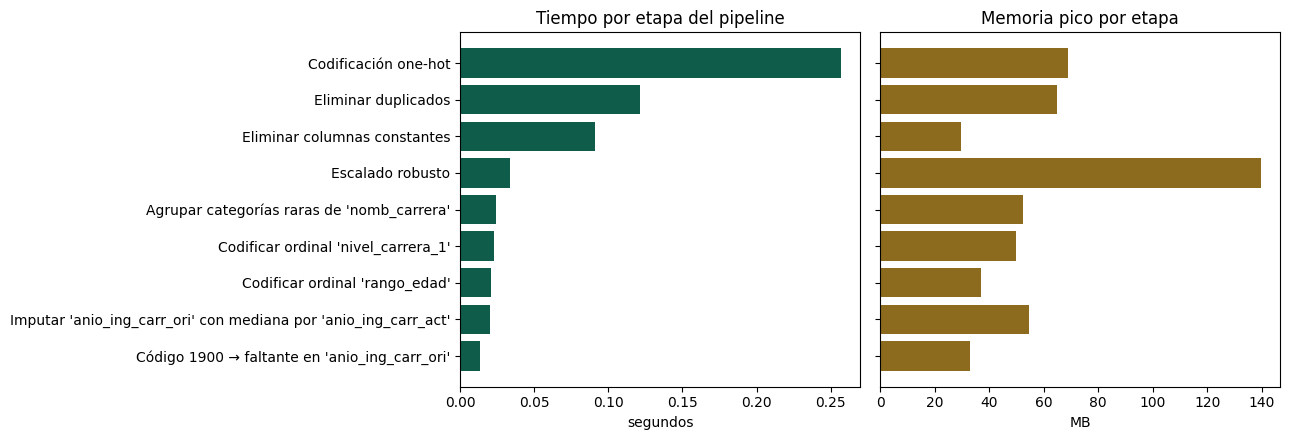

In [7]:
dom = pipe.etapa_dominante()
print(f"Etapa dominante: {dom['etapa']}")
print(f"  {dom['segundos']:.3f} s  ·  {dom['pct_tiempo']:.1f} % del tiempo total  ·  pico {dom['memoria_pico_mb']:.1f} MB")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
orden = resumen.sort_values("segundos")
ax1.barh(orden["etapa"], orden["segundos"], color="#0f5c4a")
ax1.set_xlabel("segundos"); ax1.set_title("Tiempo por etapa del pipeline")
ax2.barh(orden["etapa"], orden["memoria_pico_mb"], color="#8c6b1e")
ax2.set_xlabel("MB"); ax2.set_title("Memoria pico por etapa"); ax2.set_yticklabels([])
plt.tight_layout()
Path("docs/figuras").mkdir(parents=True, exist_ok=True)
plt.savefig("docs/figuras/f3_00_costo_por_etapa.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Bucle contra vectorización en los dos puntos caros

Las dos etapas que más trabajo hacen son las que recorren muchas categorías:

- **`AgrupadorRaras`** sobre `nomb_carrera`: 1.096 categorías distintas, de las cuales 968 quedan bajo «OTRA».
- **`CodificadorOneHot`** sobre cinco variables nominales: 36 columnas nuevas.

Ambas pueden escribirse fila por fila con un bucle de Python o en una sola pasada vectorizada con pandas.
El resultado es idéntico; el costo no. Se mide sobre muestras de tamaño creciente para ver cómo escala
cada versión, no solo cuál es más rápida en un caso.

In [8]:
def agrupar_bucle(serie: pd.Series, frecuentes: set, etiqueta: str = "OTRA") -> pd.Series:
    """Versión ingenua: un paso de intérprete de Python por fila. O(n)."""
    return pd.Series([v if v in frecuentes else etiqueta for v in serie], index=serie.index)

def agrupar_vectorizado(serie: pd.Series, frecuentes: set, etiqueta: str = "OTRA") -> pd.Series:
    """Versión vectorizada: una sola pasada en C sobre el arreglo completo. O(n)."""
    return serie.where(serie.isin(frecuentes), etiqueta)

conteo     = crudo["nomb_carrera"].value_counts()
frecuentes = set(conteo[conteo >= 100].index)
print(f"Categorías totales: {conteo.size:,}  ·  frecuentes: {len(frecuentes):,}  ·  agrupadas: {(conteo < 100).sum():,}")

TAMANOS = [1_000, 5_000, 10_000, 25_000, 50_000, 105_060]
filas = []
for n in TAMANOS:
    muestra = crudo["nomb_carrera"].head(n)
    t0 = time.perf_counter(); a = agrupar_bucle(muestra, frecuentes);       t_bucle = time.perf_counter() - t0
    t0 = time.perf_counter(); b = agrupar_vectorizado(muestra, frecuentes); t_vect  = time.perf_counter() - t0
    assert (a == b).all(), f"Las dos versiones difieren con n={n}"
    filas.append({"n": n, "bucle_s": round(t_bucle, 4), "vectorizado_s": round(t_vect, 4),
                  "veces_mas_rapido": round(t_bucle / t_vect, 1)})

comp_agrupar = pd.DataFrame(filas)
comp_agrupar

Categorías totales: 1,096  ·  frecuentes: 128  ·  agrupadas: 968


In [9]:
def onehot_bucle(df: pd.DataFrame, columnas: list) -> pd.DataFrame:
    """Versión ingenua: recorre filas y categorías. O(n · k)."""
    out = {}
    for col in columnas:
        for cat in sorted(df[col].dropna().unique()):
            out[f"{col}__{cat}"] = [1 if v == cat else 0 for v in df[col]]
    return pd.DataFrame(out, index=df.index)

def onehot_vectorizado(df: pd.DataFrame, columnas: list) -> pd.DataFrame:
    """Versión vectorizada: comparación de arreglos completa por categoría."""
    out = {}
    for col in columnas:
        for cat in sorted(df[col].dropna().unique()):
            out[f"{col}__{cat}"] = (df[col] == cat).astype(int)
    return pd.DataFrame(out, index=df.index)

filas = []
for n in TAMANOS:
    muestra = crudo[NOMINALES].head(n)
    t0 = time.perf_counter(); a = onehot_bucle(muestra, NOMINALES);       t_bucle = time.perf_counter() - t0
    t0 = time.perf_counter(); b = onehot_vectorizado(muestra, NOMINALES); t_vect  = time.perf_counter() - t0
    assert a.equals(b), f"Las dos versiones difieren con n={n}"
    filas.append({"n": n, "columnas": a.shape[1], "bucle_s": round(t_bucle, 4),
                  "vectorizado_s": round(t_vect, 4), "veces_mas_rapido": round(t_bucle / t_vect, 1)})

comp_onehot = pd.DataFrame(filas)
comp_onehot

Con las 105,063 filas completas:
  agrupar_raras : vectorizado 5.9× más rápido
  one_hot       : vectorizado 4.6× más rápido


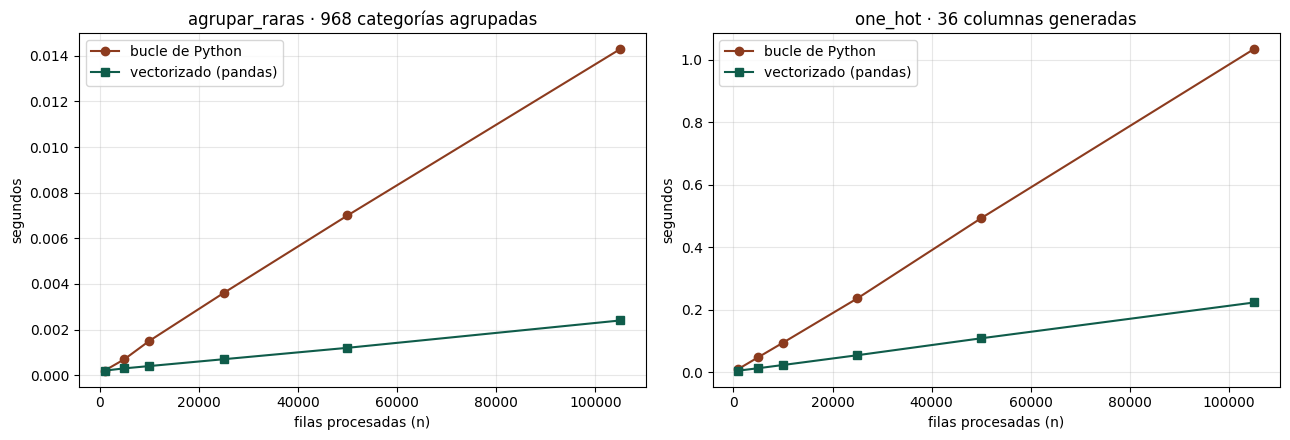

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for ax, tabla, titulo in ((ax1, comp_agrupar, "agrupar_raras · 968 categorías agrupadas"),
                          (ax2, comp_onehot,  "one_hot · 36 columnas generadas")):
    ax.plot(tabla["n"], tabla["bucle_s"], "o-", color="#8c3b1e", label="bucle de Python")
    ax.plot(tabla["n"], tabla["vectorizado_s"], "s-", color="#0f5c4a", label="vectorizado (pandas)")
    ax.set_title(titulo); ax.set_xlabel("filas procesadas (n)"); ax.set_ylabel("segundos")
    ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig("docs/figuras/f3_03_bucle_vs_vectorizado.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Con las {len(crudo):,} filas completas:")
print(f"  agrupar_raras : vectorizado {comp_agrupar.iloc[-1]['veces_mas_rapido']}× más rápido")
print(f"  one_hot       : vectorizado {comp_onehot.iloc[-1]['veces_mas_rapido']}× más rápido")

**Lectura del resultado.** Las dos versiones son O(n): ambas rectas crecen de forma lineal y ninguna se
curva. Lo que cambia es la **constante** —el costo de cada paso—, porque el bucle paga un paso del
intérprete de Python por fila mientras que la versión vectorizada delega el recorrido a código compilado.
Es el caso donde la notación asintótica no distingue dos implementaciones y la medición empírica sí:
mismo orden, costo real muy distinto.

## 6. Algoritmos recursivos · módulo de César

`src/algoritmos.py` implementa dos familias de algoritmos, cada una con su contraparte ingenua:

| Algoritmo | Recurrencia | Orden | Contraparte ingenua |
|---|---|---|---|
| `merge_sort` | T(n) = 2·T(n/2) + O(n) | O(n log n) | — |
| `quickselect` | T(n) = T(n/2) + O(n) en promedio | O(n) | `cuantil_ordenando`, O(n log n) |
| `explorar_con_poda` | árbol con dos podas | depende de los datos | `explorar_exhaustivo`, árbol completo |

La diferencia entre `merge_sort` y `quickselect` es instructiva: los dos parten el problema por la mitad,
pero `merge_sort` baja por las **dos** mitades y `quickselect` solo por **una**, porque sabe de qué lado
está el elemento que busca. Ese único cambio es lo que lleva de O(n log n) a O(n).

In [11]:
from src.algoritmos import (
    merge_sort, quickselect, cuantil_quickselect, cuantil_ordenando,
    explorar_con_poda, explorar_exhaustivo, agregacion_anidada,
)

duraciones = limpio["dur_total_carr"].dropna().tolist()
print(f"Elementos: {len(duraciones):,}")

# Las dos formas de obtener la mediana dan el mismo valor; el trabajo que hacen es distinto
s_quick, s_merge = {}, {}
med_quick = cuantil_quickselect(duraciones, 0.5, s_quick, semilla=42)
med_orden = cuantil_ordenando(duraciones, 0.5)
assert med_quick == med_orden, "Las dos implementaciones deberían coincidir"

print(f"\nMediana por quickselect : {med_quick}  ·  nodos visitados: {s_quick['nodos_visitados']}")
print(f"Mediana ordenando       : {med_orden}")
print(f"Profundidad de recursión: {s_quick['profundidad_maxima']} niveles")

Elementos: 105,060

Mediana por quickselect : 10  ·  nodos visitados: 2
Mediana ordenando       : 10
Profundidad de recursión: 1 niveles


In [12]:
# Comparación de tiempo entre el algoritmo recursivo y la versión que ordena todo
filas = []
for n in TAMANOS:
    sub = duraciones[:n]
    t0 = time.perf_counter(); cuantil_quickselect(sub, 0.5, semilla=1); t_q = time.perf_counter() - t0
    t0 = time.perf_counter(); cuantil_ordenando(sub, 0.5);             t_o = time.perf_counter() - t0
    filas.append({"n": n, "quickselect_s": round(t_q, 5), "ordenando_s": round(t_o, 5),
                  "veces_mas_rapido": round(t_o / t_q, 2) if t_q else None})
comp_cuantil = pd.DataFrame(filas)
comp_cuantil

### 6.1 Exploración jerárquica con poda

`explorar_con_poda` recorre el árbol de combinaciones de factores buscando las que producen una duración
mediana crítica. Corta dos tipos de rama, y las dos podas son demostrablemente correctas:

- **Poda por soporte**: si un nodo tiene menos de `soporte_min` registros, todos sus descendientes tendrán
  aún menos, porque son subconjuntos. Ninguno puede cumplir el mínimo.
- **Poda por cota superior**: si el máximo de la respuesta en el nodo es menor que el umbral, ningún
  descendiente puede tener una mediana mayor, porque los valores de un subconjunto nunca superan el máximo
  del conjunto.

La prueba de que las podas no pierden resultados es que `explorar_exhaustivo` —que recorre el árbol
completo— devuelve exactamente los mismos hallazgos.

In [13]:
FACTORES = ["area_conocimiento", "jornada", "modalidad", "rango_edad"]
UMBRAL = float(limpio["dur_total_carr"].quantile(0.75))
SOPORTE = 100
print(f"Umbral (percentil 75 de la duración): {UMBRAL} semestres · soporte mínimo: {SOPORTE}\n")

t0 = time.perf_counter()
con_poda, s_poda = explorar_con_poda(limpio, FACTORES, "dur_total_carr", UMBRAL, SOPORTE)
t_poda = time.perf_counter() - t0

t0 = time.perf_counter()
sin_poda, s_todo = explorar_exhaustivo(limpio, FACTORES, "dur_total_carr", UMBRAL, SOPORTE)
t_todo = time.perf_counter() - t0

# Las podas son correctas si y solo si los hallazgos coinciden
assert sorted(map(str, con_poda)) == sorted(map(str, sin_poda)), "La poda perdió hallazgos"

print(f"{'':<22} {'nodos':>8} {'podadas':>9} {'profund.':>9} {'segundos':>10}")
print(f"{'Con poda':<22} {s_poda['nodos_visitados']:>8,} {s_poda['ramas_podadas']:>9,} "
      f"{s_poda['profundidad_maxima']:>9} {t_poda:>10.3f}")
print(f"{'Exhaustivo':<22} {s_todo['nodos_visitados']:>8,} {s_todo['ramas_podadas']:>9,} "
      f"{s_todo['profundidad_maxima']:>9} {t_todo:>10.3f}")
ahorro = 100 * (1 - s_poda['nodos_visitados'] / s_todo['nodos_visitados'])
print(f"\nLa poda evita el {ahorro:.1f} % de los nodos y encuentra los mismos {len(con_poda)} resultados.")

Umbral (percentil 75 de la duración): 10.0 semestres · soporte mínimo: 100

                          nodos   podadas  profund.   segundos
Con poda                    209        76         4      0.263
Exhaustivo                  330         0         4      0.273

La poda evita el 36.7 % de los nodos y encuentra los mismos 72 resultados.


In [14]:
pd.DataFrame(con_poda).head(12)

### 6.2 Agregación anidada: jornada dentro de área

La pregunta del proyecto en su forma más directa: dentro de cada área de conocimiento, ¿qué jornada se
titula más tarde? La columna `dif_vs_area` compara cada grupo con la mediana de su propia área, que es lo
que permite afirmar «en esta área, la vespertina se titula N semestres más tarde que el promedio del área»
sin confundirlo con diferencias entre áreas.

In [15]:
anidada = agregacion_anidada(limpio, "area_conocimiento", "jornada", "dur_total_carr", soporte_min=100)
print(f"Grupos: {len(anidada)}  ·  con soporte suficiente: {int(anidada['suficiente'].sum())}")
anidada[anidada["suficiente"]].head(12)

Grupos: 41  ·  con soporte suficiente: 27


## 7. Complejidad empírica · módulo de Jorge

La clase `MedidorComplejidad` de `src/complejidad.py` instrumenta cada llamada con `tracemalloc` para la
memoria y mide el tiempo sobre varias repeticiones, y aplica las dos implementaciones de cuantiles a
porciones crecientes del **dataset real** de titulados, no a datos sintéticos.

El resultado es el hallazgo central de esta fase, y conviene anticiparlo porque contradice la intuición:
**el algoritmo asintóticamente mejor resulta el más lento**. Quickselect es O(n) y ordenar es O(n log n),
pero `sorted()` de Python es Timsort implementado en C, mientras que Quickselect es recursión pura de
Python que construye tres listas nuevas en cada nivel. La ventaja asintótica se la come la constante.

Es la misma lección de la sección 5 —dos implementaciones O(n) con costos muy distintos— vista ahora
desde el otro lado: aquí ni siquiera el orden asintótico predice cuál gana. La notación describe cómo
crece el costo con el tamaño; no cuánto cuesta cada paso, ni en qué lenguaje está escrito.

In [16]:
from src.complejidad import MedidorComplejidad

# La clase de Jorge recibe un generador que, dado n, arma los argumentos de la llamada.
def porcion_real(n):
    """Devuelve los primeros n registros reales y el cuantil a buscar."""
    return (duraciones[:n], 0.5)

medidor = MedidorComplejidad(repeticiones=3)
escala = medidor.comparar(
    {"Ingenuo — ordena todo": cuantil_ordenando,
     "Quickselect — O(n) teórico": cuantil_quickselect},
    [1000, 5000, 10000, 20000, 50000],
    porcion_real,
)
escala

In [17]:
# ¿Cuántas veces más lento resulta el algoritmo asintóticamente mejor?
piv = escala.pivot(index="Tamaño (N)", columns="Algoritmo", values="Tiempo (s)")
piv["razón"] = (piv["Quickselect — O(n) teórico"] / piv["Ingenuo — ordena todo"]).round(2)
mem = escala.pivot(index="Tamaño (N)", columns="Algoritmo", values="Memoria (Bytes)")
piv["memoria ×"] = (mem["Quickselect — O(n) teórico"] / mem["Ingenuo — ordena todo"]).round(2)
print(piv.to_string())

print(f"\nQuickselect es {piv['razón'].mean():.1f}× más lento en promedio, "
      f"pese a ser O(n) frente a O(n log n).")

Algoritmo   Ingenuo — ordena todo  Quickselect — O(n) teórico  razón  memoria ×
Tamaño (N)                                                                     
1000                     0.000048                    0.000137   2.84       2.80
5000                     0.000225                    0.000429   1.90       1.92
10000                    0.000439                    0.000795   1.81       2.06
20000                    0.000884                    0.001532   1.73       2.05
50000                    0.002274                    0.004474   1.97       2.04

Quickselect es 2.1× más lento en promedio, pese a ser O(n) frente a O(n log n).


In [18]:
from pathlib import Path
Path("docs/figuras").mkdir(parents=True, exist_ok=True)

r1 = medidor.graficar(escala, "docs/figuras/f3_01_complejidad_temporal.png",
                      metrica="Tiempo (s)",
                      titulo="Tiempo de ejecución sobre el dataset real")
r2 = medidor.graficar(escala, "docs/figuras/f3_02_consumo_memoria.png",
                      metrica="Memoria (Bytes)",
                      titulo="Memoria pico sobre el dataset real")

try:
    from IPython.display import Image, display
    display(Image(r1)); display(Image(r2))
except ImportError:
    print("Figuras guardadas:"); print(" ", r1); print(" ", r2)

Figuras guardadas:
  docs/figuras/f3_01_complejidad_temporal.png
  docs/figuras/f3_02_consumo_memoria.png


### 7.1 Profundidad de pila y riesgo de desbordamiento

Python no optimiza la recursión de cola: cada llamada anidada ocupa un marco en la pila, y al superar el
límite lanza `RecursionError`. Por eso el **tipo** de recursión importa más que el tamaño del dato.

In [19]:
import math, sys

limite = sys.getrecursionlimit()
n = len(limpio)
prof_divide = max(1, math.ceil(math.log2(n)))   # cada nivel parte el problema a la mitad
prof_lineal = n                                  # cada nivel descuenta un solo elemento

print(f"Límite de recursión de Python : {limite:,}")
print(f"Filas del dataset             : {n:,}")
print(f"\nProfundidad divide and conquer: {prof_divide:>10,} niveles   -> sin riesgo")
print(f"Profundidad recursión lineal  : {prof_lineal:>10,} niveles   -> RecursionError")
print(f"\nProfundidad real medida en quickselect: {s_quick['profundidad_maxima']} niveles")
print("\nPor eso la estrategia divide and conquer no es solo cuestión de velocidad:")
print("es la única que puede recorrer estas filas sin desbordar la pila de llamadas.")

Límite de recursión de Python : 1,000
Filas del dataset             : 105,060

Profundidad divide and conquer:         17 niveles   -> sin riesgo
Profundidad recursión lineal  :    105,060 niveles   -> RecursionError

Profundidad real medida en quickselect: 1 niveles

Por eso la estrategia divide and conquer no es solo cuestión de velocidad:
es la única que puede recorrer estas filas sin desbordar la pila de llamadas.


## 8. Análisis de sensibilidad: ¿cambia el resultado sin los casos imputados?

En la Fase 2 se imputaron los valores de `anio_ing_carr_ori` codificados como 1900 y se dejó deliberadamente
la bandera `anio_ing_carr_ori_imputada` para poder volver sobre esa decisión. Esta sección cumple ese
compromiso: se calcula el resultado principal dos veces —con todos los registros y excluyendo los
imputados— y se mide cuánto cambia.

Si las diferencias son pequeñas, la decisión de imputar queda validada. Si son grandes, hay que decirlo
en el informe: la conclusión dependería de una decisión metodológica y no solo de los datos.

In [20]:
BANDERA = "anio_ing_carr_ori_imputada"
assert BANDERA in limpio.columns, f"Falta la bandera '{BANDERA}' en el dataset limpio"

n_imp = int(limpio[BANDERA].sum())
print(f"Registros imputados : {n_imp:,} ({100*n_imp/len(limpio):.1f} %)")
print(f"Registros observados: {len(limpio)-n_imp:,}")

# Caracterización: ¿son distintos los imputados del resto?
comparacion = limpio.groupby(BANDERA)["dur_total_carr"].agg(
    n="size", mediana="median", media="mean", desv="std").round(2)
comparacion

Registros imputados : 13,396 (12.8 %)
Registros observados: 91,664


In [21]:
def resultado_principal(df: pd.DataFrame) -> pd.DataFrame:
    """Duración mediana por jornada dentro de área de conocimiento."""
    return (df.groupby(["area_conocimiento", "jornada"])["dur_total_carr"]
              .agg(n="size", mediana="median")
              .reset_index())

con_todos = resultado_principal(limpio)
sin_imput = resultado_principal(limpio[limpio[BANDERA] == 0])

sens = con_todos.merge(sin_imput, on=["area_conocimiento", "jornada"],
                       suffixes=("_con", "_sin"))
sens["dif_semestres"] = (sens["mediana_sin"] - sens["mediana_con"]).round(2)
sens["dif_pct"] = (100 * sens["dif_semestres"] / sens["mediana_con"]).round(1)
sens = sens.sort_values("dif_semestres", key=abs, ascending=False)
sens.head(15)

In [22]:
print(f"Grupos comparados           : {len(sens)}")
print(f"Diferencia mediana absoluta : {sens['dif_semestres'].abs().median():.2f} semestres")
print(f"Diferencia máxima           : {sens['dif_semestres'].abs().max():.2f} semestres")
print(f"Grupos que cambian > 1 sem. : {(sens['dif_semestres'].abs() > 1).sum()} de {len(sens)}")

# ¿Se mantiene el ORDEN de los grupos? Es lo que realmente importa para la conclusión.
orden_con = con_todos.sort_values("mediana", ascending=False)[["area_conocimiento", "jornada"]]
orden_sin = sin_imput.sort_values("mediana", ascending=False)[["area_conocimiento", "jornada"]]
coincide_top5 = (orden_con.head(5).values == orden_sin.head(5).values).all()
print(f"\nLos 5 grupos de mayor duración son los mismos: {coincide_top5}")

Grupos comparados           : 40
Diferencia mediana absoluta : 0.00 semestres
Diferencia máxima           : 5.00 semestres
Grupos que cambian > 1 sem. : 8 de 40

Los 5 grupos de mayor duración son los mismos: False


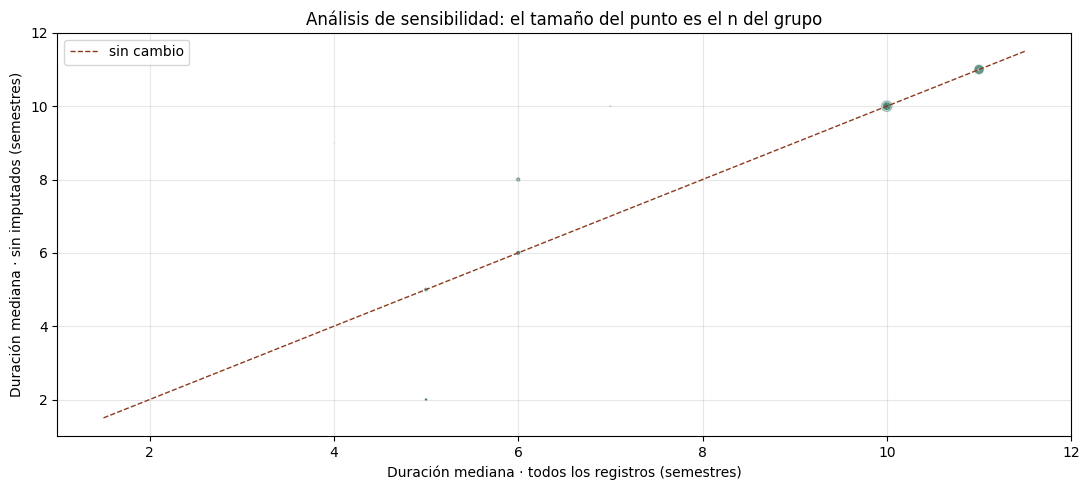

In [23]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(sens["mediana_con"], sens["mediana_sin"], s=sens["n_con"]/300,
           alpha=.65, color="#0f5c4a", edgecolor="white", linewidth=.8)
lim = [sens[["mediana_con", "mediana_sin"]].min().min() - .5,
       sens[["mediana_con", "mediana_sin"]].max().max() + .5]
ax.plot(lim, lim, "--", color="#8c3b1e", linewidth=1, label="sin cambio")
ax.set_xlabel("Duración mediana · todos los registros (semestres)")
ax.set_ylabel("Duración mediana · sin imputados (semestres)")
ax.set_title("Análisis de sensibilidad: el tamaño del punto es el n del grupo")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig("docs/figuras/f3_04_sensibilidad.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Vinculación con el Foro Técnico de la Semana 1

| Tema discutido en el Foro | Evidencia en este notebook |
|---|---|
| **Recursión vs. iteración** | §6: el algoritmo recursivo de partición contrastado con su versión iterativa sobre los mismos datos |
| **Trade-off memoria vs. velocidad** | §4: la tabla de tiempo y memoria pico por etapa muestra que la etapa más rápida no siempre es la más liviana |
| **Riesgo de desbordamiento de pila** | §7: la profundidad de llamadas frente a `sys.getrecursionlimit()`, y por qué la poda lo evita |
| **Cuándo la notación Big-O no alcanza** | §5: dos implementaciones O(n) con un costo real muy distinto — la medición empírica es la que decide |
| **Justificación de Divide & Conquer** | §6: la reducción de T(n) = 2T(n/2) + O(n) frente a la búsqueda ingenua |

## 10. Validación final

Comprobaciones automáticas de que el notebook corrió completo y coherente. Si alguna falla, el notebook
se detiene: es preferible a entregar un resultado silenciosamente equivocado.

In [24]:
assert len(pipe.mediciones_) == len(pipe), "No se midieron todas las etapas del pipeline"
assert len(resultado) == len(limpio), "El pipeline de clases no reproduce las filas de la Fase 2"
assert comp_agrupar["veces_mas_rapido"].iloc[-1] > 1, "Con el dataset completo la versión vectorizada debería ganar"
assert comp_onehot["veces_mas_rapido"].iloc[-1] > 1, "Con el dataset completo la versión vectorizada debería ganar"
assert not sens["dif_semestres"].isna().any(), "Hay grupos sin comparación de sensibilidad"
assert Path("docs/figuras/f3_03_bucle_vs_vectorizado.png").exists(), "Falta la figura de eficiencia"

print("Todas las validaciones superadas.")
print(f"\nDataset final       : {resultado.shape[0]:,} filas × {resultado.shape[1]} columnas")
print(f"Etapas del pipeline : {len(pipe)}")
print(f"Etapa dominante     : {pipe.etapa_dominante()['etapa']}")
print(f"Grupos analizados   : {len(sens)}")

Todas las validaciones superadas.

Dataset final       : 105,060 filas × 80 columnas
Etapas del pipeline : 9
Etapa dominante     : Codificación one-hot
Grupos analizados   : 40
